# Titled Tuesday Command Center
Run top-to-bottom every Tuesday morning. Update the config cell first.

In [4]:
# ── Weekly Config — update these each Tuesday ─────────────────────────────────
TOURN_DATE = "2026-09-29"   # Next Tuesday's date (YYYY-MM-DD)

# ── Attendance adjustments ─────────────────────────────────────────────────────
GLOBAL_NUDGE = 0

CUT_PLAYERS = []

KEEP_PLAYERS = []

P_OVERRIDES = {}

P_NUDGES   = {}

SAVE_OFFICIAL = True       # set True to persist to DB (do after finalising adjustments)

In [5]:
import sys
sys.path.insert(0, '..')

import re
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import requests

from kalshi_core import KalshiClient, pnl_summary, kalshi_order_price
from src.config import DB_PATH
from src.data import get_username_mappings, load_model_predictions, load_standings
from src.kalshi_tt import get_tt_asks, get_tt_positions_df
from src.trading import take_trades
from src.pipeline import run_raw, run_adjusted, load_adj_run_from_db, load_raw_results_from_db
from src.portfolio import build_portfolio, run_portfolio_mc_score
from src.visualization import (
    plot_top_players_by_chance, plot_yes_no_prices,
    plot_ip_advantage, plot_pnl_histogram,
)

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 120)

USERNAME_TO_PLAYER, PLAYER_TO_USERNAME = get_username_mappings()
print('Imports OK')

# ── Reload from DB (no simulation) ────────────────────────────────────────────
# Run this cell when re-opening the notebook to restore the last saved run.
# Rebuilds pool arrays from standings (~5s); skips the 60s MC simulation.
# Then run run_adjusted() below if attendance adjustments have changed.
adj_run     = load_adj_run_from_db(TOURN_DATE)
results_raw = load_raw_results_from_db(TOURN_DATE)
results     = adj_run.results
print(f'\nPool: {len(results):,} players (loaded from DB)')

Imports OK
  p_participate: EWMA over 55 weeks since 2025-09-02 (no season-shift, no isotonic floor)
  351 events | 10,377 unique players | 2020-01-07 to 2026-09-22
  Player pool (score): 7,116
Loaded 7,116 predictions from DB (tournament: 2026-09-29)
Loaded 7,116 raw predictions from DB (tournament: 2026-09-29)

Pool: 7,116 players (loaded from DB)


---
## 2 — Run predictions

In [3]:
# Run once — raw baseline (no attendance adjustments).
# Re-run only if historical data has been updated.
raw_run     = run_raw(TOURN_DATE, save_to_db=True)
results_raw = raw_run.results_raw
print(f'\nPool: {len(raw_run.results_raw):,} players')

Predicting for tournament date: 2026-09-29
  p_participate: EWMA over 55 weeks since 2025-09-02 (no season-shift, no isotonic floor)
  351 events | 10,377 unique players | 2020-01-07 to 2026-09-22
  Player pool (score): 7,116
  Pool: 7,116 players | simulating 100,000 tournaments (raw)...
Saved 7,116 rows -> latest_model_predictions_raw (unadjusted)

Pool: 7,116 players


In [4]:
# Re-run this cell freely as attendance data changes.
adj_run = run_adjusted(
    TOURN_DATE,
    cut_players=CUT_PLAYERS,
    keep_players=KEEP_PLAYERS,
    p_participate_overrides=P_OVERRIDES,
    p_nudges=P_NUDGES,
    global_nudge=GLOBAL_NUDGE,
    raw_run=raw_run if raw_run else None,
    save_official=SAVE_OFFICIAL,
)
results = adj_run.results
print(f'\nPool: {len(results):,} players')

  Simulating 100,000 tournaments (adjusted)...
Saved 7,116 rows -> latest_model_predictions (0 attendance_altered)

Pool: 7,116 players


---
## 4 — Top predictions table

Yellow rows had a manual adjustment applied.

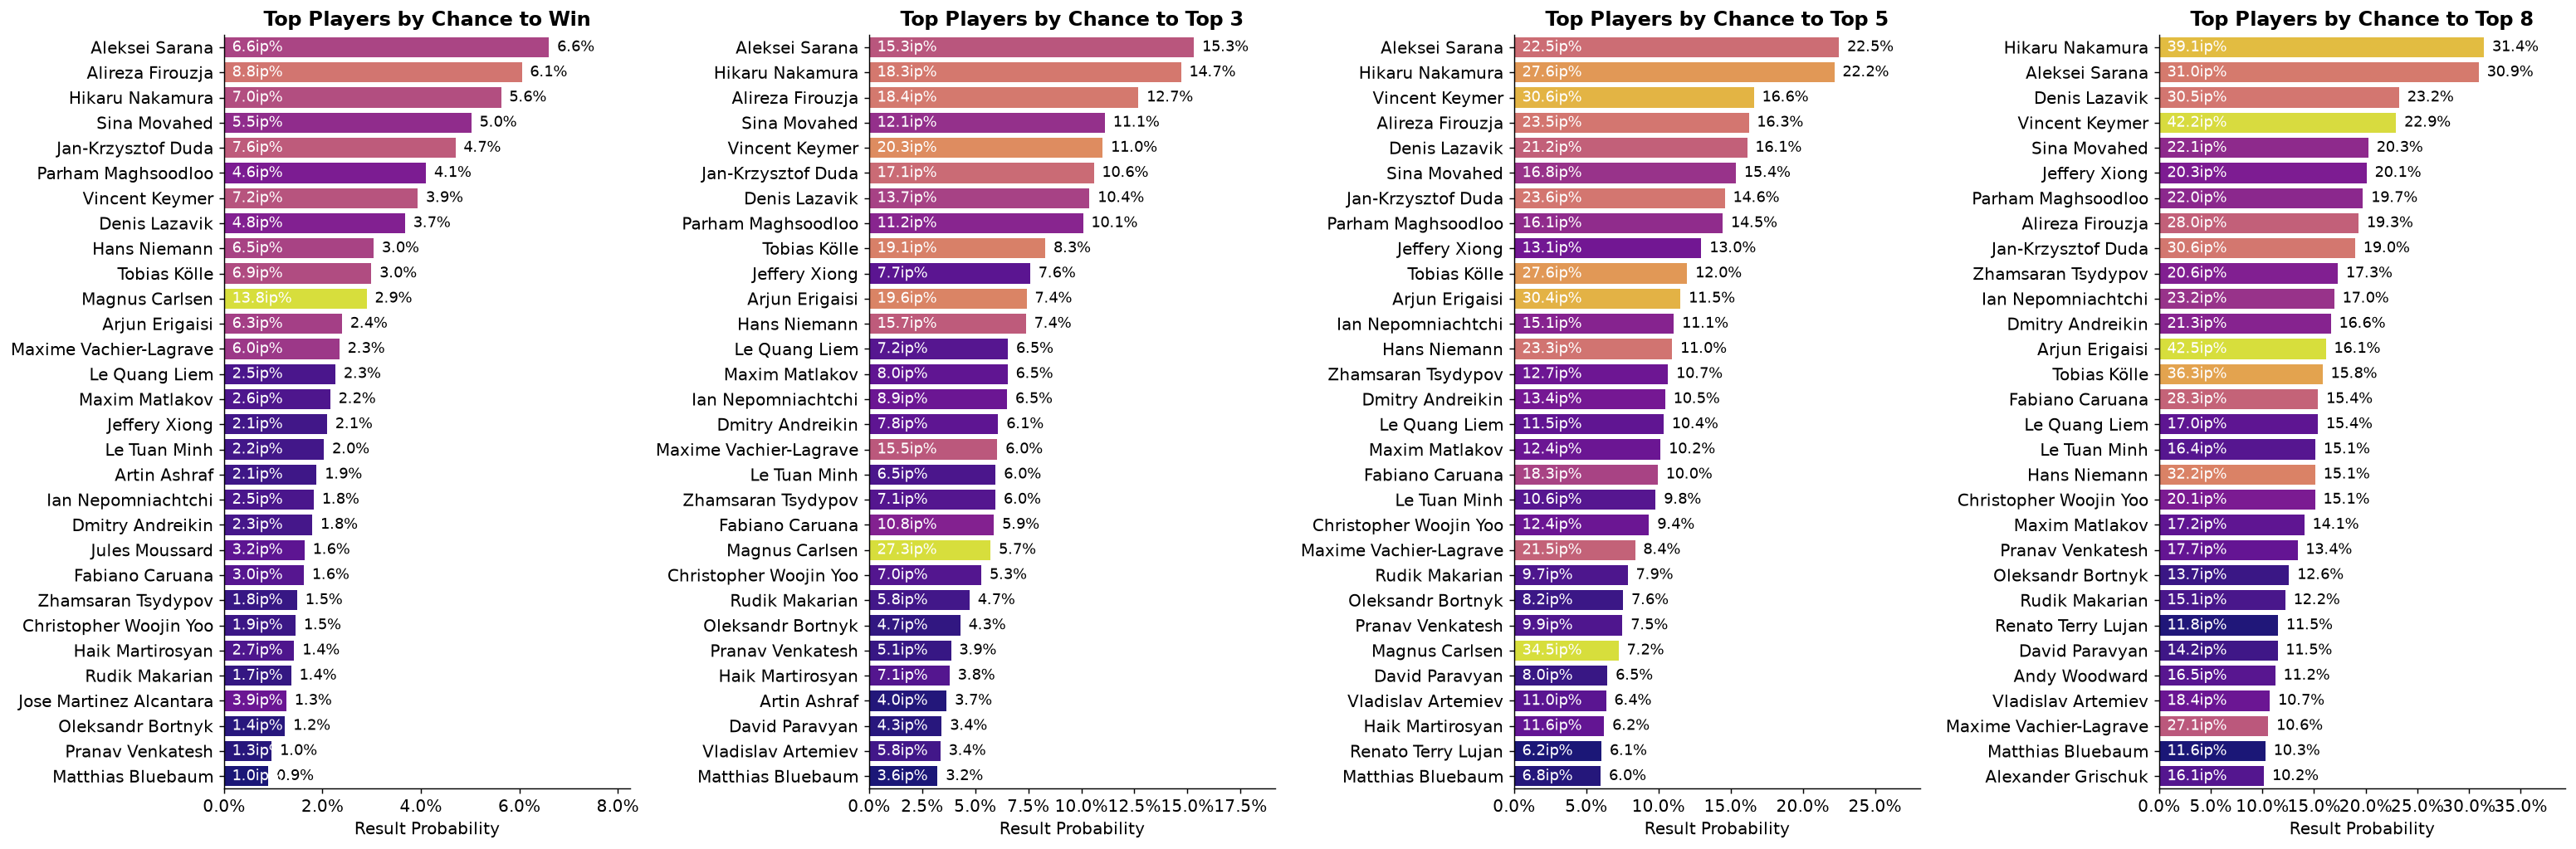

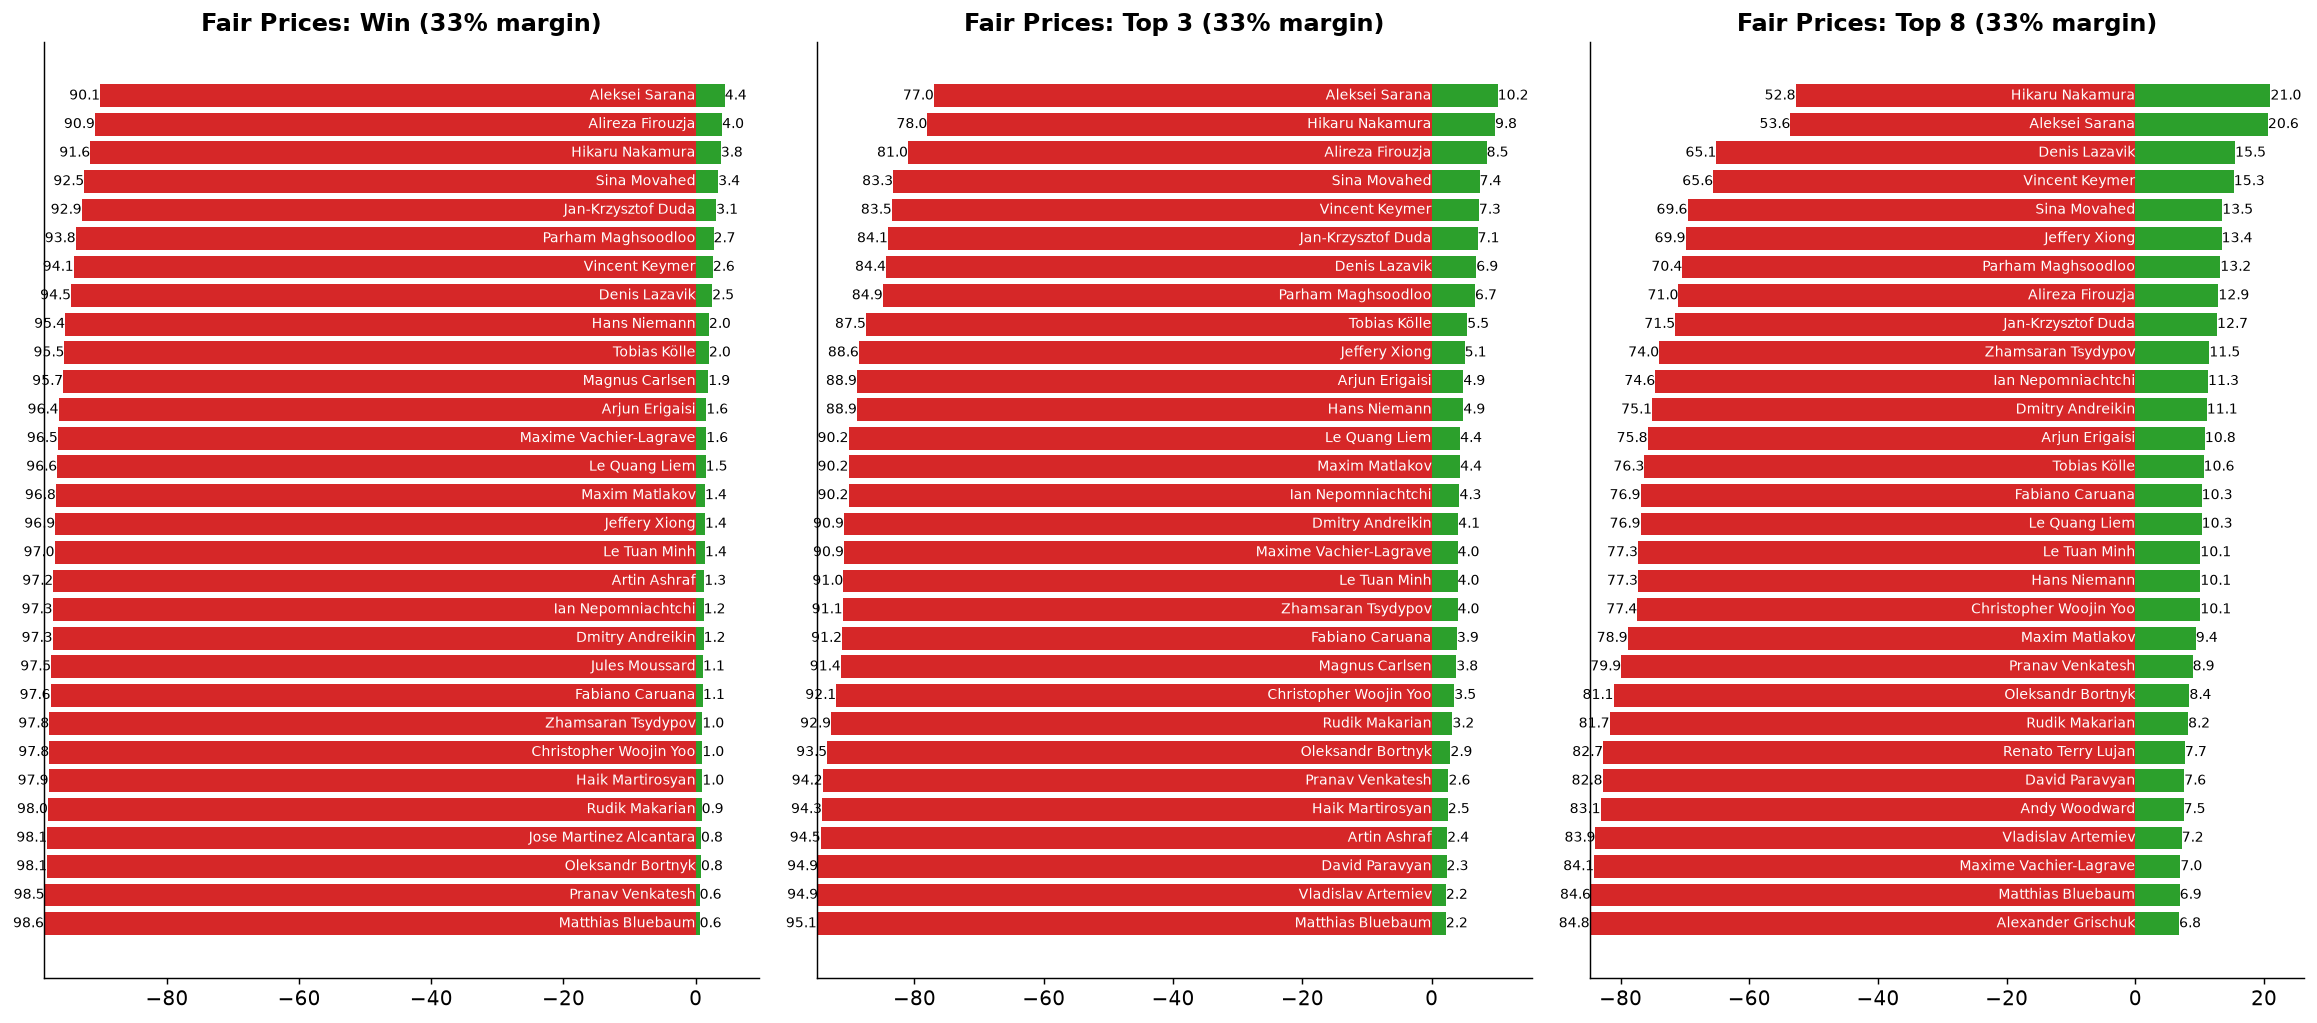

findfont: Failed to find font weight heavy, now using 700.


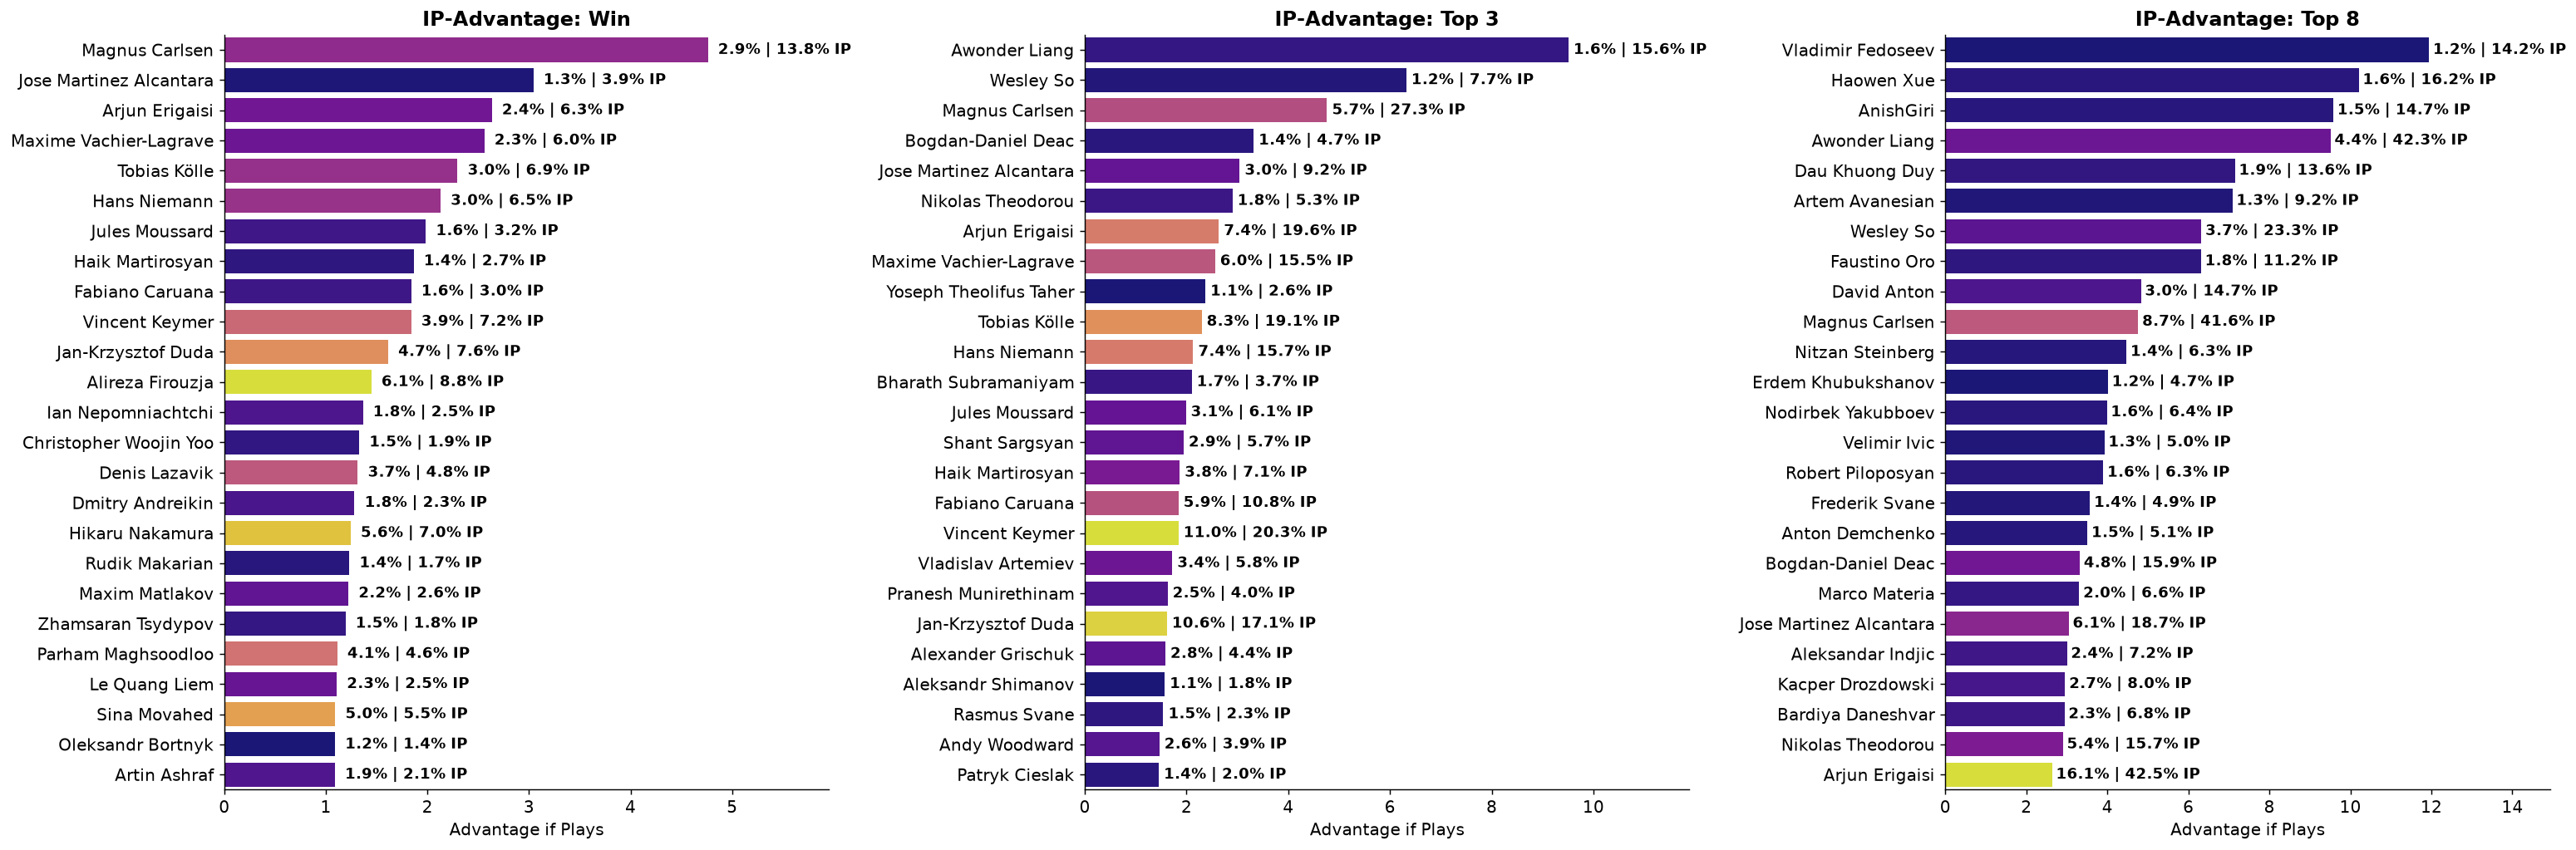

In [5]:
# ── Predictions visualizations ────────────────────────────────────────────────
plot_top_players_by_chance(results, USERNAME_TO_PLAYER)
plot_yes_no_prices(results, USERNAME_TO_PLAYER)
plot_ip_advantage(results, USERNAME_TO_PLAYER)

In [ ]:
# Plot Raw Results
plot_top_players_by_chance(results_raw, USERNAME_TO_PLAYER)
plot_yes_no_prices(results_raw, USERNAME_TO_PLAYER)
plot_ip_advantage(results_raw, USERNAME_TO_PLAYER)

---
## 5 — Portfolio P&L

Fetches current positions directly from Kalshi API for `TOURN_DATE`.


Portfolio: 5 position(s), total cost $146.32
Running P&L simulation (20k sims)...
   10,000 / 25,000  (4.0s)
   20,000 / 25,000  (7.9s)
   25,000 / 25,000  (10.2s)

Position EV breakdown:


,marketTitle,position,n,avg_price,ev_per_share,cost,ev,expected_return,roi
1,Sina Movahed,Yes,5,0.090,0.221,$0.00,$0.01,$0.01,2.461
2,Aleksei Sarana,Yes,5,0.147,0.309,$88.00,$185.28,$97.28,2.105
3,Parham Maghsoodloo,Yes,5,0.130,0.190,$26.00,$38.03,$12.02,1.462
4,Tobias Koelle,Yes,5,0.110,0.154,$11.00,$15.36,$4.36,1.397
0,Magnus Carlsen,No,5,0.650,0.805,$21.31,$26.40,$5.08,1.238



── Portfolio (25,000 simulated tournaments) ──────────────
  Mean        : $+118.75
  Std dev     : $287.18
  5th pctile  : $-146.32
  25th pctile : $-113.53
  Median      : $-13.53
  75th pctile : $+486.47
  95th pctile : $+653.73
  Worst case  : $-146.32
  Best case   : $+786.57


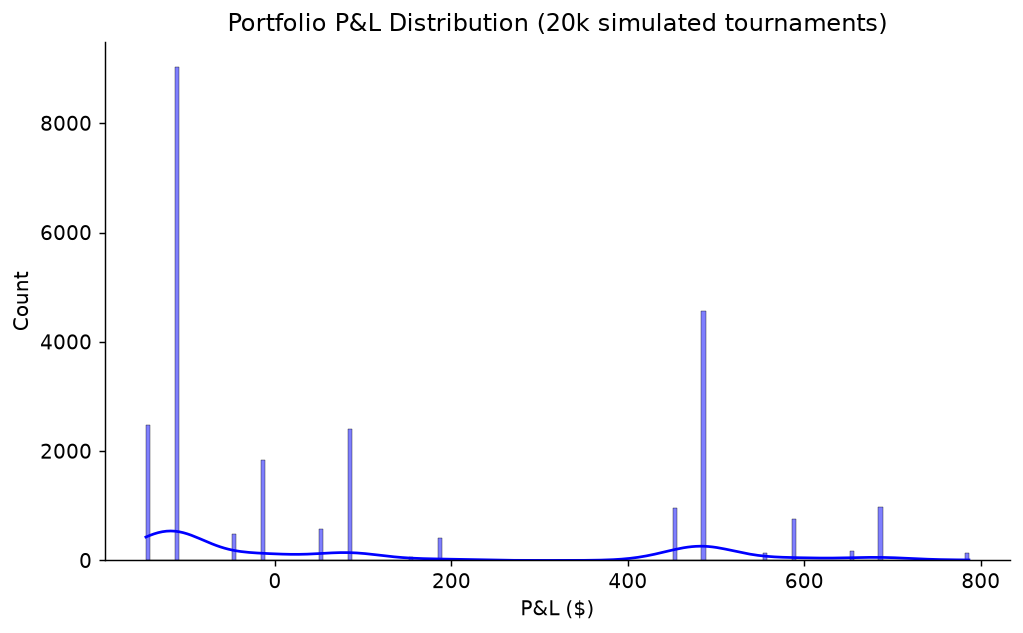

In [28]:
client = KalshiClient()
df_tt = get_tt_positions_df(client, TOURN_DATE)

if df_tt.empty:
    print(f'No TT positions found for {TOURN_DATE}.')
else:
    print(f'\nPortfolio: {len(df_tt)} position(s), total cost ${df_tt["cost"].sum():.2f}')

    portfolio = build_portfolio(df_tt, adj_run.players, PLAYER_TO_USERNAME)
    print('Running P&L simulation (20k sims)...')
    pnl, p_win = run_portfolio_mc_score(
        adj_run.players, adj_run.p_play, adj_run.hist_composites, adj_run.hist_wts,
        portfolio, n_sims=25_000,
    )

    df_tt = df_tt.copy()
    df_tt['ev_per_share'] = p_win
    df_tt['ev'] = p_win * df_tt['volume']
    df_tt['expected_return'] = df_tt['ev'] - df_tt['cost']
    df_tt['roi'] = df_tt['ev'] / df_tt['cost']

    print('\nPosition EV breakdown:')
    display(
        df_tt[['marketTitle', 'position', 'n', 'avg_price', 'ev_per_share', 'cost', 'ev', 'expected_return', 'roi']]
        .sort_values('roi', ascending=False)
        .style.format({
            'avg_price': '{:.3f}', 'ev_per_share': '{:.3f}',
            'cost': '${:.2f}', 'ev': '${:.2f}',
            'expected_return': '${:.2f}', 'roi': '{:.3f}',
        })
    )

    pnl_summary(pnl)
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.histplot(x=pnl, kde=True, ax=ax, color='blue', bins=200)
    ax.set_title('Portfolio P&L Distribution (20k simulated tournaments)')
    ax.set_xlabel('P&L ($)')
    plt.tight_layout()
    plt.show()
    plt.close(fig)

---
## 6 — Best trades (live Kalshi orderbook)

In [6]:
MIN_ROI=1.1
N_CONTRACTS=1
DRY_RUN=False

# client = KalshiClient()
# all_asks = get_tt_asks(client, TOURN_DATE)
# print(f'Fetched {len(all_asks)} orderbook levels for {TOURN_DATE}.')

_results_raw = load_model_predictions().set_index('username')
for _n in [1, 3, 5, 8, 10]:
    _results_raw[f'P_top{_n}'] = _results_raw['p_participate'] * _results_raw[f'P_top{_n}_given_play']
    _results_raw[f'ip_adv_top{_n}'] = _results_raw[f'P_top{_n}_given_play'] / _results_raw[f'P_top{_n}']
results = _results_raw

def _parse_n(title):
    """Extract top-N from market title. 'Winner' markets have no small number — return 1."""
    if re.search('Titled Tuesday Sep 22, 2026 Winner', title or '') is not None:
            return 1
    m = re.search(r'(Top\s+)(\d+)', title or '')
    if not m:
        return 1
    val = int(m.group(2))
    return val if val <= 10 else 1

df_ob = pd.DataFrame(all_asks)
df_ob['n'] = df_ob['Market Title'].apply(_parse_n)

# Resolve player names → usernames
df_ob['username'] = df_ob['Player Name'].map(lambda n: PLAYER_TO_USERNAME.get(n))
df_ob = df_ob[df_ob['username'].notna()].copy()

evs = []
for _, row in df_ob.iterrows():
    n = int(row['n'])
    col = f'P_top{n}'
    if row['username'] not in results.index or col not in results.columns:
        evs.append(None)
        continue
    p_yes = results.loc[row['username'], col]
    evs.append(float(p_yes) if row['Side'] == 'YES' else float(1.0 - p_yes))

df_ob['EV'] = evs
df_ob = df_ob[df_ob['EV'].notna()].copy()
df_ob['Order Price'] = df_ob['Ask Price ($)'].apply(kalshi_order_price)
df_ob['Total Cost']  = df_ob['Quantity Available'] * df_ob['Order Price']
df_ob['Expected Return'] = (df_ob['EV'] - df_ob['Order Price']) * df_ob['Quantity Available'].astype(int)
df_ob['ROI'] = (df_ob['EV'] / df_ob['Order Price']).round(3)

df_edge = df_ob[df_ob['ROI'] > MIN_ROI].copy()

exposure = df_edge["Total Cost"].sum()
exp_return = df_edge["Expected Return"].sum()
exp_roi = (exposure + exp_return)/exposure
print(f'Exposure (all edge positions): ${exposure:.2f}, expected return: ${exp_return:.2f}. ROI: {exp_roi:.2f}')
display(
    df_edge[['Market Title', 'n', 'Side', 'ROI', 'Order Price', 'EV', 'Quantity Available', 'Total Cost', 'Expected Return']]
    .sort_values(['n','ROI'], ascending=False)
    .style.format({
        'ROI': '{:.3f}', 'Order Price': '{:.3f}', 'EV': '{:.3f}',
        'Total Cost': '${:.2f}', 'Expected Return': '${:.2f}',
    })
)

NameError: name 'all_asks' is not defined

In [ ]:
display(
    df_edge[['Market Title', 'n', 'Side', 'ROI', 'Order Price', 'EV', 'Quantity Available', 'Total Cost', 'Expected Return']]
    .sort_values(['ROI'], ascending=False)
    .style.format({
        'ROI': '{:.3f}', 'Order Price': '{:.3f}', 'EV': '{:.3f}',
        'Total Cost': '${:.2f}', 'Expected Return': '${:.2f}',
    })
)

NameError: name 'df_edge' is not defined

In [ ]:
#Automatically take trades with ROI > min_roi for the given date and max trades count.
result = take_trades(
        client,
        tourn_date=TOURN_DATE,
        min_roi=MIN_ROI,
        min_qty=20,
        dry_run=False,
    )

TypeError: take_trades() got an unexpected keyword argument 'count'

In [ ]:
display(
    df_edge[['Market Title', 'Side', 'ROI', 'Order Price', 'EV', 'Quantity Available', 'Total Cost', 'Expected Return']][df_edge['Side']=='NO']
    .sort_values('ROI', ascending=False)
    .style.format({
        'ROI': '{:.3f}', 'Order Price': '{:.3f}', 'EV': '{:.3f}',
        'Total Cost': '${:.2f}', 'Expected Return': '${:.2f}',
    })
)

,Market Title,Side,ROI,Order Price,EV,Quantity Available,Total Cost,Expected Return


In [ ]:
# ── Kelly sizing ──────────────────────────────────────────────────────────────
df_pos = df_edge.copy()
df_pos['kelly_f'] = (df_pos['EV'] - df_pos['Order Price']) / (1.0 - df_pos['Order Price'])

total_f = df_pos['kelly_f'].sum()
if total_f > 1.0:
    print(f'Sum of single-bet Kelly fractions = {total_f:.2f} — normalising to 1.0')
    df_pos['kelly_f'] /= total_f

df_pos['alloc_frac']   = df_pos['kelly_f'] * KELLY_MULT
df_pos['kelly_shares'] = (df_pos['alloc_frac'] * BANKROLL / df_pos['Order Price']).round().clip(lower=0).astype(int)
df_pos['kelly_cost']   = df_pos['kelly_shares'] * df_pos['Order Price']
df_pos['kelly_ev']     = df_pos['kelly_shares'] * df_pos['EV']
df_pos['kelly_edge']   = df_pos['kelly_ev'] - df_pos['kelly_cost']

df_kelly = df_pos[df_pos['kelly_shares'] > 0].copy()
total_cost = df_kelly['kelly_cost'].sum()
total_ev   = df_kelly['kelly_ev'].sum()
print(
    f'Bankroll ${BANKROLL:,.0f}  |  '
    f'Exposure ${total_cost:.0f} ({total_cost/BANKROLL*100:.1f}%)  |  '
    f'Expected edge ${total_ev - total_cost:.2f}  |  '
    f'Portfolio ROI {(total_ev/total_cost - 1)*100:.1f}%\n'
)
display(
    df_kelly[['Market Title', 'Side', 'ROI', 'Order Price', 'EV',
              'kelly_f', 'alloc_frac', 'kelly_shares', 'kelly_cost', 'kelly_edge']]
    .sort_values('kelly_f', ascending=False)
    .style.format({
        'Order Price': '{:.3f}', 'EV': '{:.3f}',
        'kelly_f': '{:.4f}', 'alloc_frac': '{:.4f}',
        'kelly_cost': '${:.2f}', 'kelly_edge': '${:.2f}',
    })
)

Sum of single-bet Kelly fractions = 3.54 — normalising to 1.0


NameError: name 'KELLY_MULT' is not defined